<a href="https://colab.research.google.com/github/Keerthika-N/F1/blob/main/LEC_SAI_Tire_Degradation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install fastf1
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import pandas as pd
import numpy as np
import os

os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

In [4]:
session = fastf1.get_session(2024, 'Abu Dhabi', 'R')
session.load(laps=True)
laps = session.laps
tire_data = laps[['Driver', 'Compound', 'TyreLife', 'Stint', 'LapNumber','LapTime']]
sai_tire_data=tire_data.pick_driver('SAI')
sai_tire_data['LapTimeSeconds'] = sai_tire_data['LapTime'].dt.total_seconds()
stint1 = sai_tire_data.loc[sai_tire_data['Stint'] == 1]

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core     

In [5]:
session = fastf1.get_session(2024, 'Abu Dhabi', 'R')
session.load(laps=True)
laps = session.laps
tire_data = laps[['Driver', 'Compound', 'TyreLife', 'Stint', 'LapNumber','LapTime']]
lec_tire_data=tire_data.pick_driver('LEC')
lec_tire_data['LapTimeSeconds'] = lec_tire_data['LapTime'].dt.total_seconds()
stint2 = lec_tire_data.loc[lec_tire_data['Stint'] == 1]

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
INFO:fastf1.fastf1.core:Loading data for Abu Dhabi Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core     

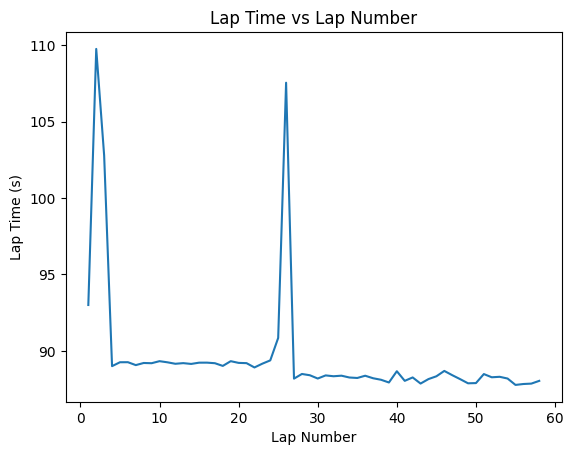

In [6]:
plt.plot(sai_tire_data['LapNumber'], sai_tire_data['LapTimeSeconds'])
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (s)')
plt.title('Lap Time vs Lap Number')
plt.show()

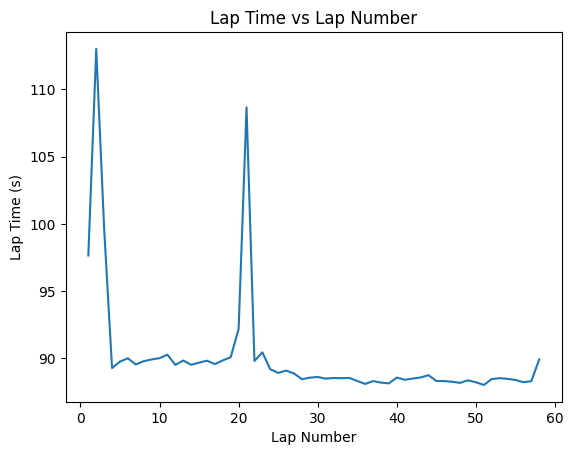

In [7]:
plt.plot(lec_tire_data['LapNumber'], lec_tire_data['LapTimeSeconds'])
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (s)')
plt.title('Lap Time vs Lap Number')
plt.show()

Sainz's tire degradation rate in Stint 1:  0.020 seconds per lap


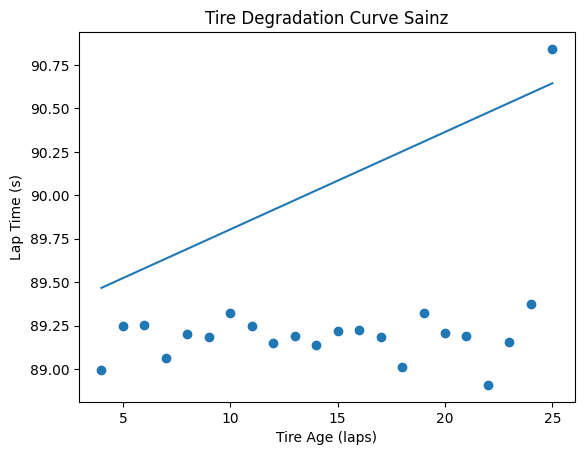

In [12]:
median_time1 = stint1['LapTimeSeconds'].median()
stint_clean1 = stint1[stint1['LapTimeSeconds'] < 91]
z = np.polyfit(stint_clean1['TyreLife'], stint_clean1['LapTimeSeconds'], 1)
deg_rate=z[0]
print(f"Sainz's tire degradation rate in Stint 1: {deg_rate: .3f} seconds per lap")
p_sai = np.poly1d(z)
plt.scatter(stint_clean1['TyreLife'], stint_clean1['LapTimeSeconds'])
plt.plot(stint_clean1['TyreLife'],p(stint_clean1 ['TyreLife']))
plt.xlabel('Tire Age (laps)')
plt.ylabel('Lap Time (s)')
plt.title('Tire Degradation Curve Sainz')
plt.show()

Leclerc's tire degradation rate in Stint 1:  0.056 seconds per lap


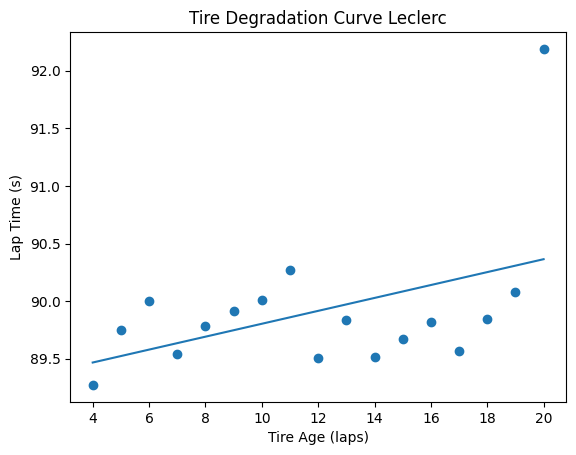

In [13]:
median_time2 = stint2['LapTimeSeconds'].median()
stint_clean2 = stint2[stint2['LapTimeSeconds'] < 95]
z = np.polyfit(stint_clean2['TyreLife'], stint_clean2['LapTimeSeconds'], 1)
deg_rate=z[0]
print(f"Leclerc's tire degradation rate in Stint 1: {deg_rate: .3f} seconds per lap")
p_lec = np.poly1d(z)
plt.scatter(stint_clean2['TyreLife'], stint_clean2['LapTimeSeconds'])
plt.plot(stint_clean2['TyreLife'],p(stint_clean2['TyreLife']))
plt.xlabel('Tire Age (laps)')
plt.ylabel('Lap Time (s)')
plt.title('Tire Degradation Curve Leclerc')
plt.show()

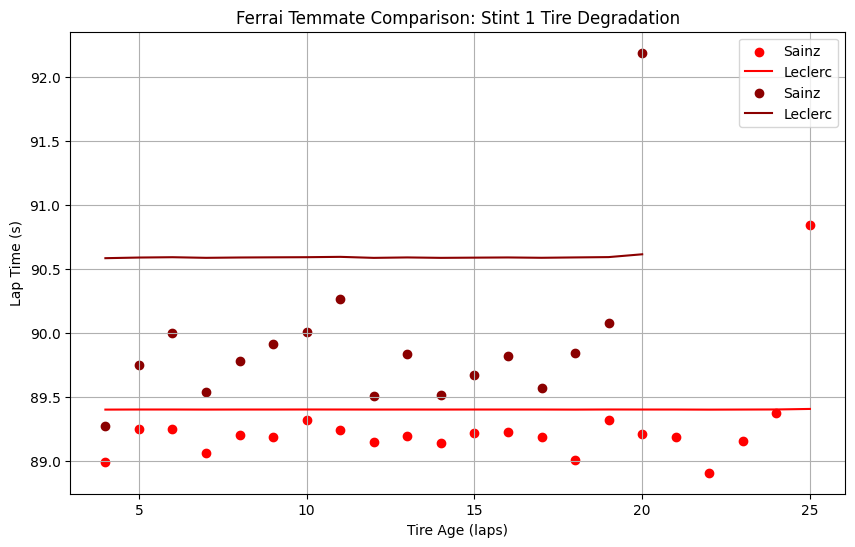

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(stint_clean1['TyreLife'], stint_clean1['LapTimeSeconds'], label='Sainz', color = 'red')
plt.plot(stint_clean1['TyreLife'], p_sai(stint_clean1['LapTimeSeconds']), label='Leclerc', color = 'red')

plt.scatter(stint_clean2['TyreLife'], stint_clean2['LapTimeSeconds'], label='Sainz', color = 'darkred')
plt.plot(stint_clean2['TyreLife'], p_lec(stint_clean2['LapTimeSeconds']), label='Leclerc', color = 'darkred')

plt.title("Ferrai Temmate Comparison: Stint 1 Tire Degradation")
plt.xlabel("Tire Age (laps)")
plt.ylabel("Lap Time (s)")
plt.grid(True)
plt.legend()

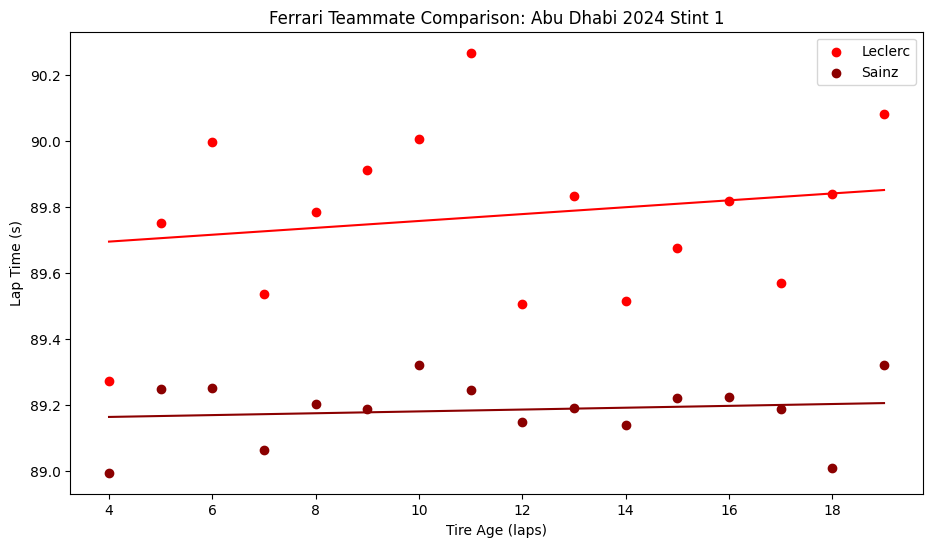

In [18]:
lec_clean = lec_tire_data[(lec_tire_data['Stint'] == 1) &
                          (lec_tire_data['LapTimeSeconds'] < 95) &
                          (lec_tire_data['TyreLife'] < 20)]
sai_clean = sai_tire_data[(sai_tire_data['Stint'] == 1) &
                          (sai_tire_data['LapTimeSeconds'] < 91) &
                          (sai_tire_data['TyreLife'] < 20)]
z_lec = np.polyfit(lec_clean['TyreLife'], lec_clean['LapTimeSeconds'], 1)
z_sai = np.polyfit(sai_clean['TyreLife'], sai_clean['LapTimeSeconds'], 1)

p_lec = np.poly1d(z_lec)
p_sai = np.poly1d(z_sai)

plt.figure(figsize=(11, 6))
plt.scatter(lec_clean['TyreLife'], lec_clean['LapTimeSeconds'], label='Leclerc', color = 'red')
plt.scatter(sai_clean['TyreLife'], sai_clean['LapTimeSeconds'], label='Sainz', color = 'darkred')
plt.plot(lec_clean['TyreLife'], p_lec(lec_clean['TyreLife']), color = 'red')
plt.plot(sai_clean['TyreLife'], p_sai(sai_clean['TyreLife']), color = 'darkred')

plt.xlabel('Tire Age (laps)')
plt.ylabel('Lap Time (s)')
plt.title('Ferrari Teammate Comparison: Abu Dhabi 2024 Stint 1')
plt.legend()
plt.show()

